In [32]:
import cv2
import nibabel as nib
import pandas as pd
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt
import torch
import glob
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose, 
    ResizeWithPadOrCropd,
    EnsureChannelFirstd,
    NormalizeIntensityd
)
from sklearn.model_selection import train_test_split

In [2]:
path = "../TotalSpineSeg"
vol_paths = glob.glob(path + "/data/sub*T2w.nii.gz") #os.listdir(path + "/data")
# vol_paths = glob.glob(path + "/data/sub*T1w.nii.gz") #os.listdir(path + "/data")

# y = "sub-4646740_acq-sag_rec-3666319702_T2w.nii.gz" 
y = np.random.choice(vol_paths).split("/")[-1]
# y = "sub-52397721_acq-sag_rec-2452297573_T2w.nii.gz"
x = y[:-7]
x = x+"_0000.nii.gz"
vol = nib.load(path+"/output/input/"+x).get_fdata()
seg = nib.load(path+"/output/step2_output/"+y).get_fdata()
print("subj :", y)

## TODO ##

# split sagittal T1 volumes into left-right subvolumes
# create a dataset for foraminal narrowing
# for this end, check images orientation

subj : sub-2048265504_acq-sag_rec-2998592741_T2w.nii.gz


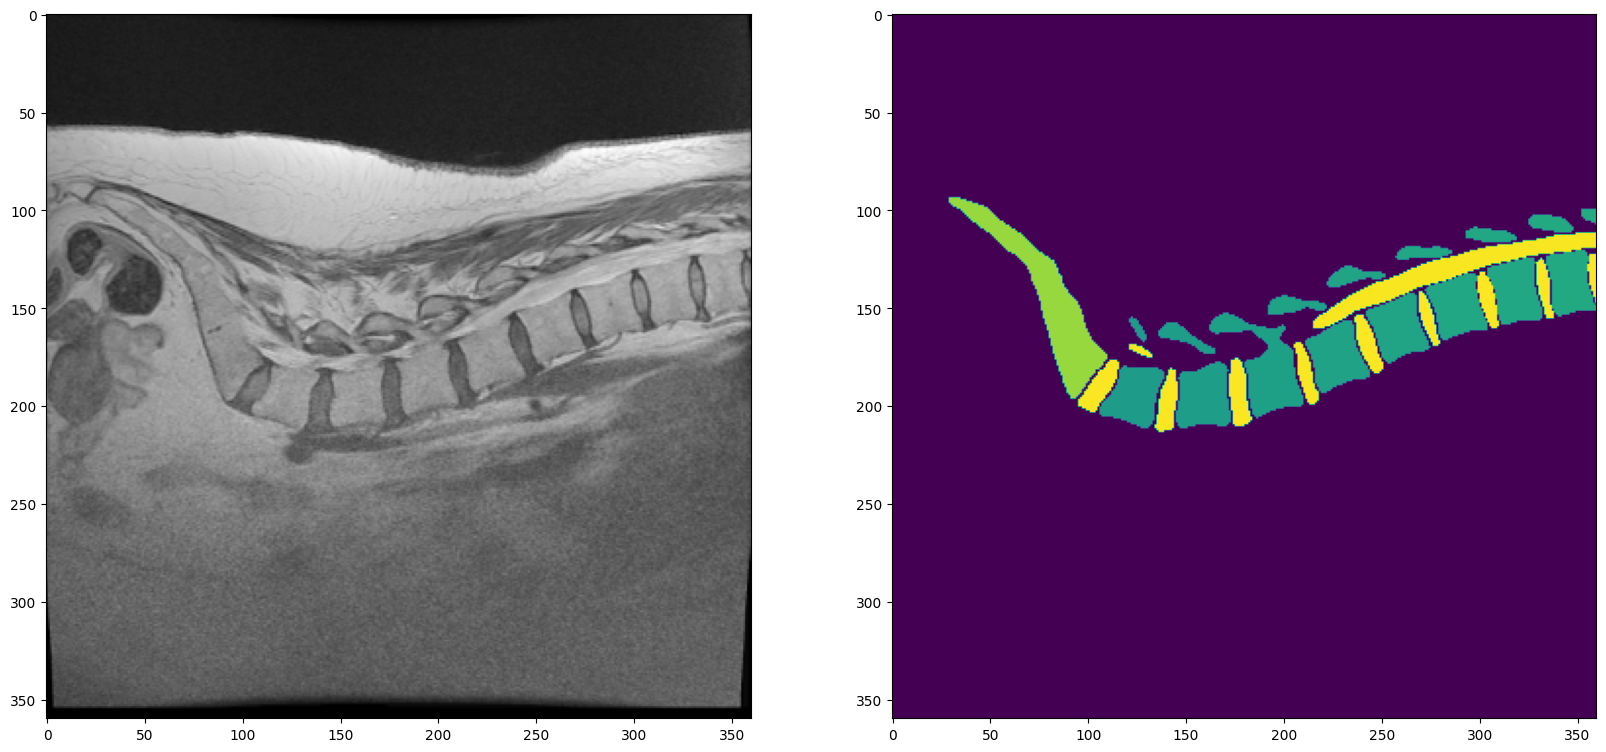

In [4]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=2)
ax[0].imshow(vol[42]**.5, cmap="gray")
ax[1].imshow(np.log(seg[42]+1))
plt.show()

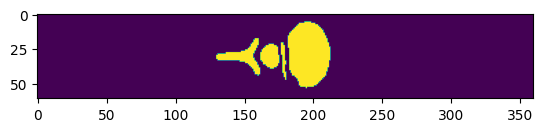

In [5]:
mask = np.isin(seg, [201, 202, 203, 204, 205, 200, 92, 18, 19, 20, 21, 22]).astype(int)
plt.imshow(mask[:,:,180])

In [6]:
discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
disc_l5 = np.isin(seg, [202]).astype(int)
disc_l4 = np.isin(seg, [203]).astype(int)
disc_l3 = np.isin(seg, [204]).astype(int)
disc_l2 = np.isin(seg, [205]).astype(int)
disc_l1 = np.isin(seg, [206]).astype(int)

In [43]:
def patch_extraction(vol, mask, d=0, h=20, w=20):
    """
    Extract a ROI from a volume with a given segmentation mask.

    vol : array of shape (D, H, W)
    mask : segmentation mask of shape (D, H, W)
    d, h, w : margin for each image axis
    """
    
    D, H, W = vol.shape
    mask = torch.Tensor(mask)
    nonzero_indices = torch.nonzero(mask)  # Extracting non-zero indices from the first channel

    d_min, h_min, w_min = nonzero_indices.min(0)[0]  # Minimum indices
    d_max, h_max, w_max = nonzero_indices.max(0)[0]  # Maximum indices
    w = 20
    
    patch = vol[max(0, d_min-d):min(D, d_max + d), 
                max(0, h_min - h):min(H, h_max + h), 
                max(0, w_min - w):min(W, w_max + w)]

    return patch

(46, 73, 55)
(46, 76, 54)
(50, 76, 53)
(51, 73, 52)
(45, 69, 63)


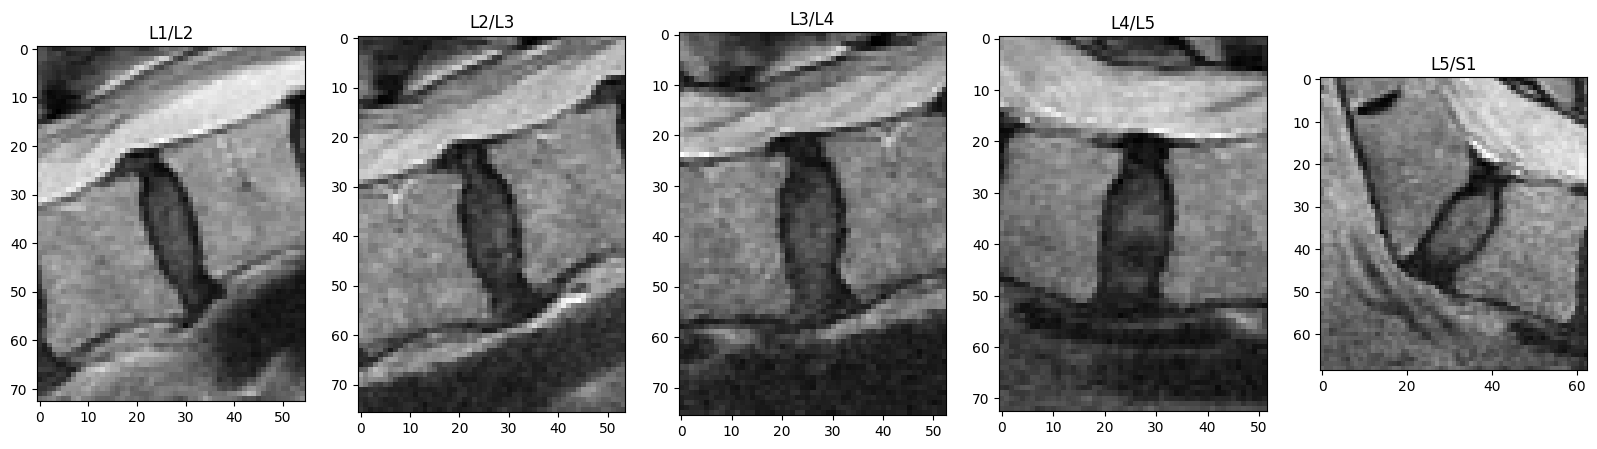

In [44]:
discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
disc_l5 = np.isin(seg, [202]).astype(int)
disc_l4 = np.isin(seg, [203]).astype(int)
disc_l3 = np.isin(seg, [204]).astype(int)
disc_l2 = np.isin(seg, [205]).astype(int)
disc_l1 = np.isin(seg, [206]).astype(int)

discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

fig, ax = plt.subplots(ncols=5, figsize=(20, 10))

D, H, W = vol.shape

for i, disc in enumerate(discs):

    patch = patch_extraction(vol, disc, d=0, h=20, w=20)
    print(patch.shape)
    d, h, w = patch.shape
    ax[i].imshow(patch[d//2], cmap="gray")
    ax[i].set_title(levels[i])

In [8]:
# patch size = (16, 64, 64) ?

In [9]:
patch.shape

(46, 69, 63)

In [10]:
d_min, d_max

(tensor(12), tensor(57))

In [11]:
w = 20
patch = vol[max(0, d_min-w):d_max + w, 
            h_min-w:h_max+w, 
            w_min-w:w_max+w]
patch.shape

(61, 69, 63)

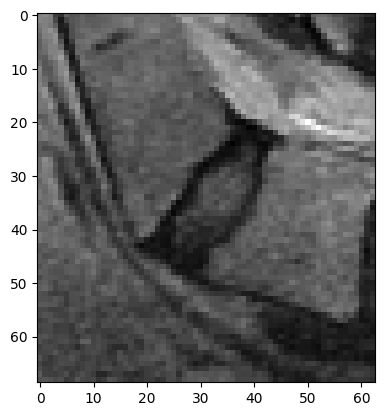

In [12]:
plt.imshow(patch[30,:,:], cmap="gray")
plt.show()

In [13]:
test = pd.read_csv("data/train.csv")

In [14]:
test[test["study_id"]==100206310]

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
45,100206310,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Severe,...,Normal/Mild,Normal/Mild,Moderate,Severe,Moderate,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate


In [45]:
class SpinalCanalStenosisDataset(Dataset):
    def __init__(self, 
                 vol_paths : list = None,
                 seg_paths : list = None,
                 labels_csv : str = "data/train.csv",
                 transform : any = None):
        
        
        text2int = {"Normal/Mild": 0, "Moderate": 1, "Severe": 2}
        vol_paths.sort()
        seg_paths.sort()
        self.vol_paths = vol_paths
        self.seg_paths = seg_paths
        self.transform = transform
        
        self.labels = pd.read_csv(labels_csv)
        self.labels = self.labels[["study_id",
                                   "spinal_canal_stenosis_l1_l2",
                                   "spinal_canal_stenosis_l2_l3",
                                   "spinal_canal_stenosis_l3_l4",
                                   "spinal_canal_stenosis_l4_l5",
                                   "spinal_canal_stenosis_l5_s1"]]
        self.labels = self.labels.replace(text2int)
        
    def __len__(self):
        return len(self.vol_paths)
        
    def __getitem__(self, idx):
        
        vol_path = self.vol_paths[idx]
        x = vol_path.split("/")[-1]
        x = x[:-7]+"_0000.nii.gz"
        
        vol = nib.load(path+"/output/input/"+x).get_fdata()
        
        study_id = x.split("_")[0][4:]
        
        seg_path = self.seg_paths[idx]
        label = self.labels[self.labels["study_id"]==int(study_id)].values[0,1:].astype(int)
        
        vol = nib.load(path+"/output/input/"+x).get_fdata()
        seg = nib.load(seg_path).get_fdata()
        
        D, H, W = vol.shape
        discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
        disc_l5 = np.isin(seg, [202]).astype(int)
        disc_l4 = np.isin(seg, [203]).astype(int)
        disc_l3 = np.isin(seg, [204]).astype(int)
        disc_l2 = np.isin(seg, [205]).astype(int)
        disc_l1 = np.isin(seg, [206]).astype(int)

        discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
        levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
        patches = {}
        
        w = 20
        for i, disc in enumerate(discs):
            patch = patch_extraction(vol, disc, d=0, h=20, w=20)
            patches[levels[i]] = torch.Tensor(patch[None])
                
        if self.transform is not None:
            patches = self.transform(patches)
        
        return patches, label       

In [33]:
transform = Compose(
    [
        NormalizeIntensityd(keys=["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]),
        ResizeWithPadOrCropd(keys=["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"],
                             spatial_size=(8, 64, 64)),
    ]    
)

root_dir="../TotalSpineSeg"
vol_paths = glob.glob(root_dir + "/data/sub*T2w.nii.gz")
seg_paths = glob.glob(root_dir+"/output/step2_output/*T2w.nii.gz")
vol_paths.sort()
seg_paths.sort()

train_vols, val_vols, train_seg, val_seg = train_test_split(vol_paths, seg_paths, test_size=0.3)

dataset = SpinalCanalStenosisDataset(vol_paths=train_vols, seg_paths=train_seg, transform=transform)
len(dataset)

1354

In [37]:
patches, label = dataset.__getitem__(np.random.randint(1354))

In [38]:
patches["L1/L2"].shape

torch.Size([1, 8, 64, 64])

[0 1 1 2 0]
[0 0 0 2 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 2 0]
[0 2 1 0 0]
[0 0 0 0 0]
[0 0 2 1 0]
[0 0 0 0 0]
[0 0 0 0 0]


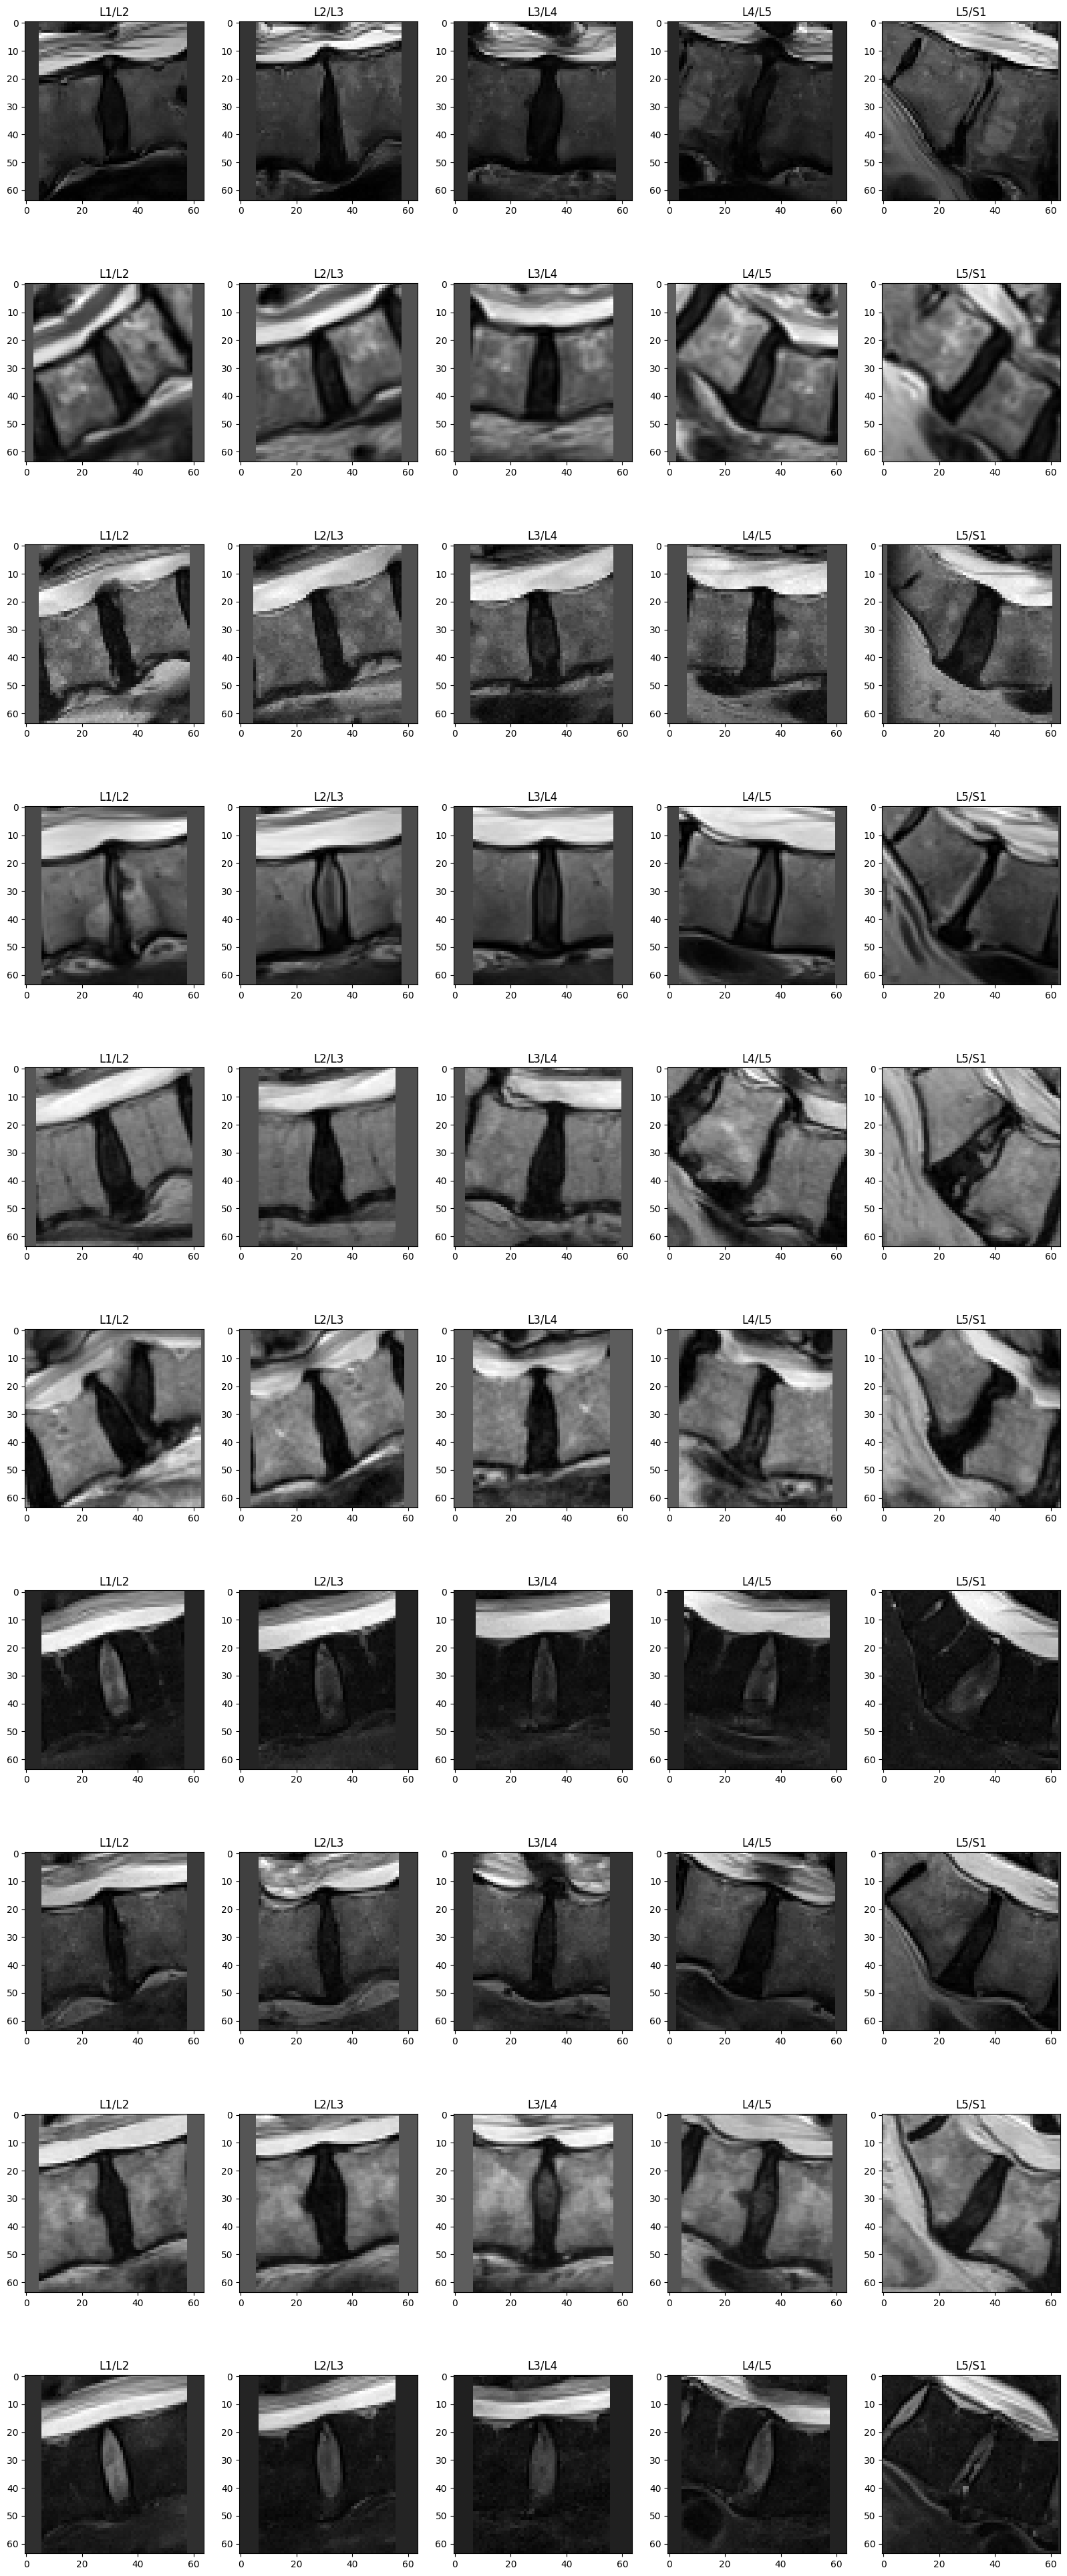

In [41]:
levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
fig, ax = plt.subplots(nrows=10, ncols=5, figsize=(20, 50))

for k in range(10):
    patches, label = dataset.__getitem__(np.random.randint(1354))
    print(label)
    for i, level in enumerate(levels):
        patch = patches[level]
        c, d, h, w = patch.shape
        ax[k, i].imshow(patch[0, d//2], cmap="gray")
        ax[k, i].set_title(levels[i])

In [28]:
728*728

529984

In [22]:
loader = DataLoader(dataset)